In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from minhash import *
from lsh import *

In [74]:
#Jaccard extraction
documents = {
    "D1": load_document("minhash/D1.txt"),
    "D2": load_document("minhash/D2.txt"),
    "D3": load_document("minhash/D3.txt"),
    "D4": load_document("minhash/D4.txt")
}
pairs = all_pairs(documents.keys())
for k_type in ["char2", "char3", "word2"]:
    print("\n---", k_type, "---")
    for d1, d2 in pairs:
        if k_type == "char2":
            s1 = char_kgrams(documents[d1], 2)
            s2 = char_kgrams(documents[d2], 2)
        elif k_type == "char3":
            s1 = char_kgrams(documents[d1], 3)
            s2 = char_kgrams(documents[d2], 3)
        else:
            s1 = word_kgrams(documents[d1], 2)
            s2 = word_kgrams(documents[d2], 2)
        print(d1, d2, jaccard(s1, s2))


--- char2 ---
D1 D2 0.9811320754716981
D1 D3 0.8156996587030717
D1 D4 0.6444444444444445
D2 D3 0.8
D2 D4 0.6412698412698413
D3 D4 0.6529968454258676

--- char3 ---
D1 D2 0.977979274611399
D1 D3 0.5803571428571429
D1 D4 0.3050847457627119
D2 D3 0.5680473372781065
D2 D4 0.30590339892665475
D3 D4 0.31212381771281167

--- word2 ---
D1 D2 0.9407665505226481
D1 D3 0.18234165067178504
D1 D4 0.03024193548387097
D2 D3 0.1736641221374046
D2 D4 0.030303030303030304
D3 D4 0.01607142857142857


In [75]:
#MinHash
char3_sets = {name: char_kgrams(text, 3) for name, text in documents.items()}
universe = build_universe(char3_sets)
for t in [20, 60, 150, 300, 600]:
    hash_funcs = generate_hash_functions(t)
    sig1 = minhash_signature(char3_sets["D1"], universe, hash_funcs)
    sig2 = minhash_signature(char3_sets["D2"], universe, hash_funcs)
    print("t =", t, "→", approx_jaccard(sig1, sig2))

t = 20 → 1.0
t = 60 → 0.9833333333333333
t = 150 → 0.96
t = 300 → 0.9933333333333333
t = 600 → 0.9816666666666667


In [76]:
#LSH signatures
r = 4
b = 40
t = 160
hash_funcs = generate_hash_functions(t)
signatures = {}
for name in documents:
    signatures[name] = minhash_signature(char3_sets[name], universe, hash_funcs)
candidates = lsh_candidates(signatures, r, b)
print("Candidate pairs:", candidates)

Candidate pairs: {('D2', 'D3'), ('D1', 'D3'), ('D1', 'D2')}


In [77]:

T = 0.7
r = 4
b = 40
t = 160
hash_funcs = generate_hash_functions(t)
signatures = {name: minhash_signature(char3_sets[name], universe, hash_funcs)
              for name in documents}
print(f"Threshold T = {T}, r = {r}, b = {b}, t = {t}\n")
for (d1, d2), sim in pair_sims.items():
    prob = lsh_probability(sim, r, b)
    print(f"{d1}-{d2}: Jaccard={sim:.3f}, Probability={prob:.3f}")

Threshold T = 0.7, r = 4, b = 40, t = 160

D1-D2: Jaccard=0.978, Probability=1.000
D1-D3: Jaccard=0.580, Probability=0.992
D1-D4: Jaccard=0.305, Probability=0.294
D2-D3: Jaccard=0.568, Probability=0.988
D2-D4: Jaccard=0.306, Probability=0.297
D3-D4: Jaccard=0.312, Probability=0.317


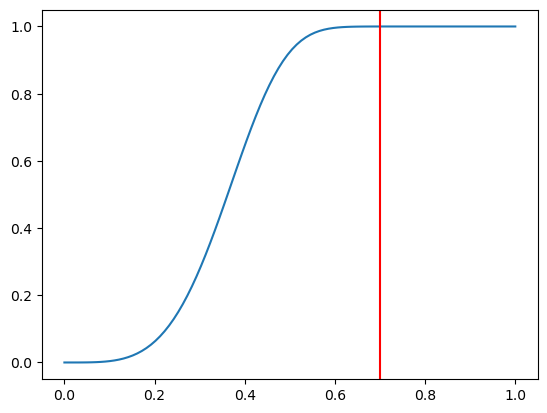

In [78]:
#Plot S-curve
s_vals = np.linspace(0,1,100)
plt.plot(s_vals, [lsh_probability(s,r,b) for s in s_vals])
plt.axvline(0.7, color='red')
plt.show()

In [79]:
import random
import itertools
from collections import defaultdict
user_movies = defaultdict(set)
with open(r"C:\Users\chnds\project\movielens\u.data", "r") as f:
    for line in f:
        user, movie, rating, timestamp = line.strip().split("\t")
        user = int(user)
        movie = int(movie)
        user_movies[user].add(movie)
users = list(user_movies.keys())
all_movies = set()
for movies in user_movies.values():
    all_movies.update(movies)
universe_dict = {movie: idx for idx, movie in enumerate(all_movies)}
print("Total users:", len(users))

Total users: 943


In [80]:
exact_pairs_05 = set()
for u1, u2 in itertools.combinations(users, 2):
    if jaccard(user_movies[u1], user_movies[u2]) >= 0.5:
        exact_pairs_05.add((u1, u2))
print("Exact pairs ≥ 0.5:", len(exact_pairs_05))

Exact pairs ≥ 0.5: 10


In [81]:
def run_experiment(t):
    fp_list = []
    fn_list = []
    for run in range(5):
        print(f"\nRunning t={t}, Run {run+1}")
        hash_funcs = generate_hash_functions(t)
        signatures = {}
        for user in users:
            signatures[user] = minhash_signature(
                user_movies[user],
                universe_dict,
                hash_funcs
            )
        approx_pairs = []
        for i in range(len(users)):
            for j in range(i+1, len(users)):
                u1 = users[i]
                u2 = users[j]
                matches = sum(
                    1 for k in range(t)
                    if signatures[u1][k] == signatures[u2][k]
                )
                est_sim = matches / t

                if est_sim >= 0.5:
                    approx_pairs.append((u1, u2))
        print("Estimated pairs ≥ 0.5:", len(approx_pairs))
        fp, fn = evaluate(approx_pairs, exact_pairs_05)
        print("False Positives:", fp)
        print("False Negatives:", fn)
        fp_list.append(fp)
        fn_list.append(fn)
    avg_fp = sum(fp_list) / 5
    avg_fn = sum(fn_list) / 5
    print("\nAverage FP:", avg_fp)
    print("Average FN:", avg_fn)

In [82]:
for t in [50, 100, 200]:
    run_experiment(t)


Running t=50, Run 1
Estimated pairs ≥ 0.5: 69
False Positives: 62
False Negatives: 3

Running t=50, Run 2
Estimated pairs ≥ 0.5: 169
False Positives: 163
False Negatives: 4

Running t=50, Run 3
Estimated pairs ≥ 0.5: 133
False Positives: 123
False Negatives: 0

Running t=50, Run 4
Estimated pairs ≥ 0.5: 199
False Positives: 193
False Negatives: 4

Running t=50, Run 5
Estimated pairs ≥ 0.5: 190
False Positives: 185
False Negatives: 5

Average FP: 145.2
Average FN: 3.2

Running t=100, Run 1
Estimated pairs ≥ 0.5: 43
False Positives: 35
False Negatives: 2

Running t=100, Run 2
Estimated pairs ≥ 0.5: 48
False Positives: 41
False Negatives: 3

Running t=100, Run 3
Estimated pairs ≥ 0.5: 37
False Positives: 29
False Negatives: 2

Running t=100, Run 4
Estimated pairs ≥ 0.5: 50
False Positives: 45
False Negatives: 5

Running t=100, Run 5
Estimated pairs ≥ 0.5: 54
False Positives: 45
False Negatives: 1

Average FP: 39.0
Average FN: 2.6

Running t=200, Run 1
Estimated pairs ≥ 0.5: 20
False Posi

In [83]:
exact_pairs_06 = set()
exact_pairs_08 = set()

for i in range(len(users)):
    for j in range(i+1, len(users)):
        u1 = users[i]
        u2 = users[j]
        sim = jaccard(user_movies[u1], user_movies[u2])
        if sim >= 0.6:
            exact_pairs_06.add((u1, u2))
        if sim >= 0.8:
            exact_pairs_08.add((u1, u2))
print("Exact ≥ 0.6:", len(exact_pairs_06))
print("Exact ≥ 0.8:", len(exact_pairs_08))

Exact ≥ 0.6: 3
Exact ≥ 0.8: 1


In [84]:
def run_lsh_experiment(t, r, b, threshold, exact_pairs):
    if r * b != t:
        raise ValueError("r * b must equal t")
    fp_list = []
    fn_list = []
    for run in range(5):
        print(f"\nRunning t={t}, r={r}, b={b}, threshold={threshold}, Run {run+1}")
        hash_funcs = generate_hash_functions(t)
        signatures = {}
        for user in users:
            signatures[user] = minhash_signature(
                user_movies[user],
                universe_dict,
                hash_funcs
            )
        candidate_pairs = lsh_candidates(signatures, r, b)
        print("Candidate pairs:", len(candidate_pairs))
        approx_pairs = set()
        for (u1, u2) in candidate_pairs:
            sig1 = signatures[u1]
            sig2 = signatures[u2]
            matches = sum(1 for i in range(t) if sig1[i] == sig2[i])
            est_sim = matches / t
            if est_sim >= threshold:
                approx_pairs.add(tuple(sorted((u1, u2))))
        print("Pairs ≥ threshold:", len(approx_pairs))
        fp = len(approx_pairs - exact_pairs)
        fn = len(exact_pairs - approx_pairs)
        print("False Positives:", fp)
        print("False Negatives:", fn)
        fp_list.append(fp)
        fn_list.append(fn)
    avg_fp = sum(fp_list) / 5
    avg_fn = sum(fn_list) / 5
    print("\nAverage FP:", avg_fp)
    print("Average FN:", avg_fn)
    return avg_fp, avg_fn

In [85]:
run_lsh_experiment(50, 5, 10, 0.6, exact_pairs_06)
run_lsh_experiment(100, 5, 20, 0.6, exact_pairs_06)
run_lsh_experiment(200, 5, 40, 0.6, exact_pairs_06)
run_lsh_experiment(200, 10, 20, 0.6, exact_pairs_06)


Running t=50, r=5, b=10, threshold=0.6, Run 1
Candidate pairs: 485
Pairs ≥ threshold: 5
False Positives: 2
False Negatives: 0

Running t=50, r=5, b=10, threshold=0.6, Run 2
Candidate pairs: 446
Pairs ≥ threshold: 9
False Positives: 7
False Negatives: 1

Running t=50, r=5, b=10, threshold=0.6, Run 3
Candidate pairs: 431
Pairs ≥ threshold: 2
False Positives: 0
False Negatives: 1

Running t=50, r=5, b=10, threshold=0.6, Run 4
Candidate pairs: 800
Pairs ≥ threshold: 9
False Positives: 7
False Negatives: 1

Running t=50, r=5, b=10, threshold=0.6, Run 5
Candidate pairs: 1192
Pairs ≥ threshold: 6
False Positives: 4
False Negatives: 1

Average FP: 4.0
Average FN: 0.8

Running t=100, r=5, b=20, threshold=0.6, Run 1
Candidate pairs: 878
Pairs ≥ threshold: 4
False Positives: 1
False Negatives: 0

Running t=100, r=5, b=20, threshold=0.6, Run 2
Candidate pairs: 1447
Pairs ≥ threshold: 4
False Positives: 1
False Negatives: 0

Running t=100, r=5, b=20, threshold=0.6, Run 3
Candidate pairs: 1027
Pair

(0.2, 1.6)

In [86]:
run_lsh_experiment(50, 5, 10, 0.8, exact_pairs_08)
run_lsh_experiment(100, 5, 20, 0.8, exact_pairs_08)
run_lsh_experiment(200, 5, 40, 0.8, exact_pairs_08)
run_lsh_experiment(200, 10, 20, 0.8, exact_pairs_08)


Running t=50, r=5, b=10, threshold=0.8, Run 1
Candidate pairs: 1396
Pairs ≥ threshold: 0
False Positives: 0
False Negatives: 1

Running t=50, r=5, b=10, threshold=0.8, Run 2
Candidate pairs: 514
Pairs ≥ threshold: 1
False Positives: 0
False Negatives: 0

Running t=50, r=5, b=10, threshold=0.8, Run 3
Candidate pairs: 401
Pairs ≥ threshold: 1
False Positives: 0
False Negatives: 0

Running t=50, r=5, b=10, threshold=0.8, Run 4
Candidate pairs: 413
Pairs ≥ threshold: 1
False Positives: 0
False Negatives: 0

Running t=50, r=5, b=10, threshold=0.8, Run 5
Candidate pairs: 452
Pairs ≥ threshold: 1
False Positives: 0
False Negatives: 0

Average FP: 0.0
Average FN: 0.2

Running t=100, r=5, b=20, threshold=0.8, Run 1
Candidate pairs: 1121
Pairs ≥ threshold: 1
False Positives: 0
False Negatives: 0

Running t=100, r=5, b=20, threshold=0.8, Run 2
Candidate pairs: 1287
Pairs ≥ threshold: 1
False Positives: 0
False Negatives: 0

Running t=100, r=5, b=20, threshold=0.8, Run 3
Candidate pairs: 634
Pair

(0.0, 0.0)